In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

plt.rcParams["figure.dpi"] = 130

In [2]:
@njit
def monte_carlo_DLA(height, width, num_particles, p_s, max_steps=200000):
    """
    Monte Carlo DLA (random walker) on a grid.

    Parameters
    ----------
    height, width : int
        Grid size.
    num_particles : int
        Total number of occupied sites in the final cluster (including the seed).
    p_s : float
        Sticking probability (assignment notation).
    max_steps : int
        Safety limit per walker (if too long, we just respawn a new walker).

    Returns
    -------
    cluster : 2D int array (height x width)
        1 for cluster sites, 0 otherwise.
    """
    cluster = np.zeros((height, width), dtype=np.int32)

    # seed at bottom middle (assignment: seed at bottom of domain)
    seed_y = height - 1
    seed_x = width // 2
    cluster[seed_y, seed_x] = 1

    # 4-neighbour directions (dx, dy)
    directions = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]], dtype=np.int32)

    # we already placed the seed
    n_in_cluster = 1

    while n_in_cluster < num_particles:
        # release a walker at random x on the top boundary
        x = np.random.randint(0, width)
        y = 0

        steps = 0
        while steps < max_steps:
            steps += 1

            # random move
            k = np.random.randint(0, 4)
            dx, dy = directions[k, 0], directions[k, 1]
            x_new = x + dx
            y_new = y + dy

            # periodic boundary left/right
            if x_new < 0:
                x_new = width - 1
            elif x_new >= width:
                x_new = 0

            # if leaving system top/bottom: remove walker (respawn a new one)
            if y_new < 0 or y_new >= height:
                break

            # walker cannot enter the cluster
            if cluster[y_new, x_new] == 1:
                # "reject" this move, try another step
                continue

            # accept move
            x, y = x_new, y_new

            # check if current position is adjacent to cluster (4-neighbour)
            next_to_cluster = False
            for i in range(4):
                nx = x + directions[i, 0]
                ny = y + directions[i, 1]

                # periodic in x for neighbour check
                if nx < 0:
                    nx = width - 1
                elif nx >= width:
                    nx = 0

                if 0 <= ny < height and cluster[ny, nx] == 1:
                    next_to_cluster = True
                    break

            # stick with probability p_s
            if next_to_cluster:
                if np.random.random() < p_s:
                    cluster[y, x] = 1
                    n_in_cluster += 1
                    break  # release next walker

        # if steps hits max_steps, we just respawn another walker

    return cluster

In [3]:
def plot_DLA_clusters(clusters, title=None):
    """
    clusters: dict {p_s: cluster_array}
    """
    ps_list = list(clusters.keys())
    n = len(ps_list)

    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]

    for ax, p_s in zip(axes, ps_list):
        ax.imshow(clusters[p_s], origin="lower", interpolation="nearest")
        ax.set_title(rf"$p_s={p_s}$")
        ax.set_xticks([])
        ax.set_yticks([])

    if title is not None:
        fig.suptitle(title, y=1.02)

    plt.tight_layout()
    plt.show()

In [4]:
def _box_count(binary_img, box_size):
    h, w = binary_img.shape
    count = 0
    for i in range(0, h, box_size):
        for j in range(0, w, box_size):
            if np.any(binary_img[i:i+box_size, j:j+box_size]):
                count += 1
    return count


def fractal_dimension(binary_img, min_box=1, max_box=None):
    """
    Box-counting fractal dimension (lecture: fractal dimension / box-counting).
    This is an estimate, not an exact value.
    """
    if max_box is None:
        max_box = min(binary_img.shape) // 2

    sizes = []
    counts = []

    s = min_box
    while s <= max_box:
        sizes.append(s)
        counts.append(_box_count(binary_img, s))
        s *= 2

    sizes = np.array(sizes, dtype=float)
    counts = np.array(counts, dtype=float)

    # avoid log(0)
    mask = counts > 0
    sizes = sizes[mask]
    counts = counts[mask]

    # log N(s) = -D log s + C
    slope, intercept = np.polyfit(np.log(sizes), np.log(counts), 1)
    return float(-slope)


def radius_of_gyration(cluster):
    """
    Radius of gyration (lecture: compactness measure).
    """
    pts = np.column_stack(np.nonzero(cluster))  # (y, x)
    if pts.shape[0] == 0:
        return 0.0
    com = pts.mean(axis=0)
    d2 = ((pts - com) ** 2).sum(axis=1)
    return float(np.sqrt(d2.mean()))

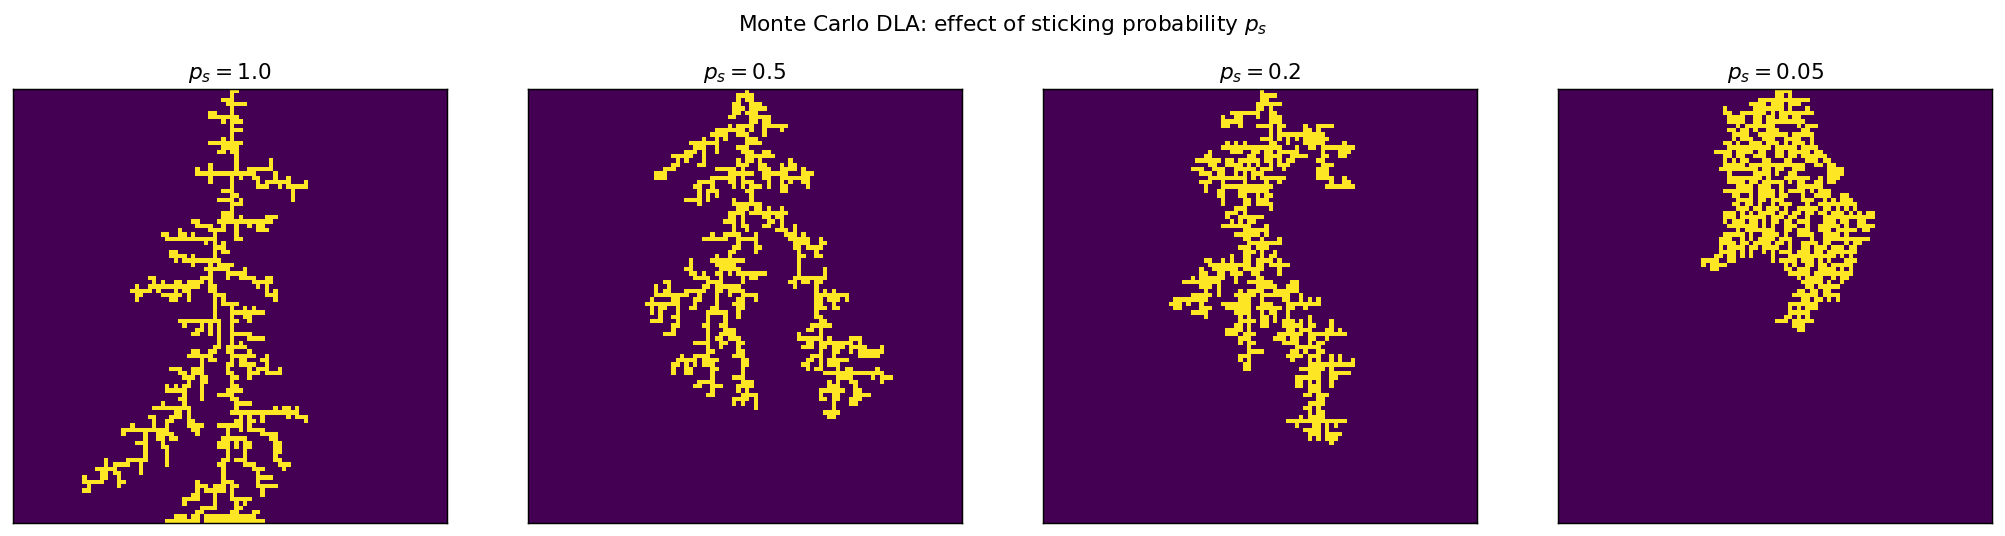

In [5]:
# ---- (D) show clusters for different sticking probabilities ----
height, width = 100, 100
num_particles = 800

ps_for_pictures = [1.0, 0.5, 0.2, 0.05]

clusters_for_pictures = {}
for p_s in ps_for_pictures:
    clusters_for_pictures[p_s] = monte_carlo_DLA(height, width, num_particles, p_s)

plot_DLA_clusters(clusters_for_pictures, title="Monte Carlo DLA: effect of sticking probability $p_s$")

In [6]:
outdir = "outputs"
os.makedirs(outdir, exist_ok=True)

for p_s, cl in clusters_for_pictures.items():
    np.save(os.path.join(outdir, f"cluster_ps_{p_s}.npy"), cl)
    plt.imsave(os.path.join(outdir, f"cluster_ps_{p_s}.png"), cl, origin="lower")
print("Saved cluster images and arrays to:", outdir)

Saved cluster images and arrays to: outputs


In [7]:
def analyse_clusters(ps_list, Nrep, height, width, num_particles):
    """
    For each p_s, run Nrep simulations and compute mean/std of:
    - fractal dimension
    - radius of gyration
    """
    D_mean, D_std = [], []
    Rg_mean, Rg_std = [], []

    for p_s in ps_list:
        Ds = []
        Rgs = []
        for r in range(Nrep):
            cl = monte_carlo_DLA(height, width, num_particles, float(p_s))
            Ds.append(fractal_dimension(cl))
            Rgs.append(radius_of_gyration(cl))

        D_mean.append(float(np.mean(Ds)))
        D_std.append(float(np.std(Ds)))
        Rg_mean.append(float(np.mean(Rgs)))
        Rg_std.append(float(np.std(Rgs)))

    return D_mean, D_std, Rg_mean, Rg_std


def plot_cluster_metrics(ps_list, D_mean, D_std, Rg_mean, Rg_std):
    # fractal dimension vs p_s
    plt.figure(figsize=(4.6, 3.2))
    plt.errorbar(ps_list, D_mean, yerr=D_std, fmt='-o', capsize=2, markersize=4)
    plt.xlabel(r"$p_s$")
    plt.ylabel("Fractal dimension (box-counting)")
    plt.xlim(0, 1.02)
    plt.tight_layout()
    plt.show()

    # radius of gyration vs p_s (optional but nice)
    plt.figure(figsize=(4.6, 3.2))
    plt.errorbar(ps_list, Rg_mean, yerr=Rg_std, fmt='-o', capsize=2, markersize=4)
    plt.xlabel(r"$p_s$")
    plt.ylabel(r"Radius of gyration $R_g$")
    plt.xlim(0, 1.02)
    plt.tight_layout()
    plt.show()

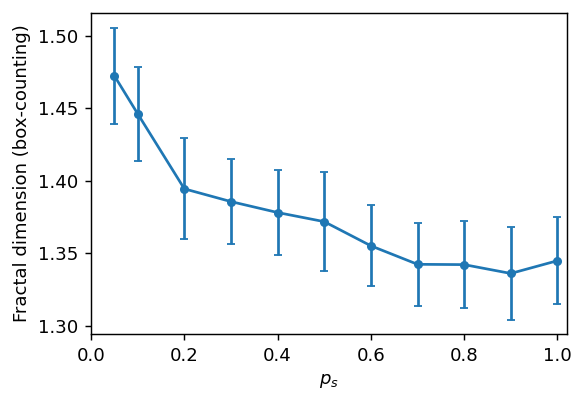

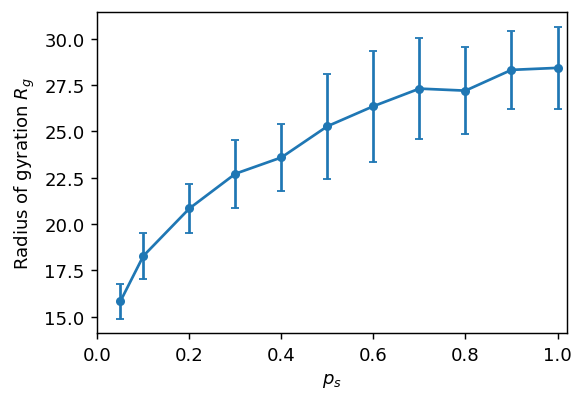

In [8]:
# ---- sweep p_s values (as in the assignment / your senior's list) ----
ps = [0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
Nrep = 25  # can try 5 first if you want a quick check

D_mean, D_std, Rg_mean, Rg_std = analyse_clusters(ps, Nrep, height, width, num_particles)
plot_cluster_metrics(ps, D_mean, D_std, Rg_mean, Rg_std)